In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path

from bsrl_fit.diagnostics import (
    arviz_summary,
    corner_plot,
    credible_limits,
    load_chain,
    plot_traces,
)

CHAIN_PATH = Path("../results/chain_m3.h5")
PARAM_NAMES = ["N_main", "sigma", "f_sat", "f_ghost", "t0", "background"]
LOG_PARAMS = ("f_sat", "f_ghost")

In [ ]:
# load the chain and log_prob
samples, log_prob = load_chain(CHAIN_PATH)
print("chain shape:", samples.shape)  # expect (nsteps, nwalkers, 6)
print("log_prob shape:", log_prob.shape)

chain shape: (5000, 32, 6)
log_prob shape: (5000, 32)


### 1. Trace - checking convergence of the sampler

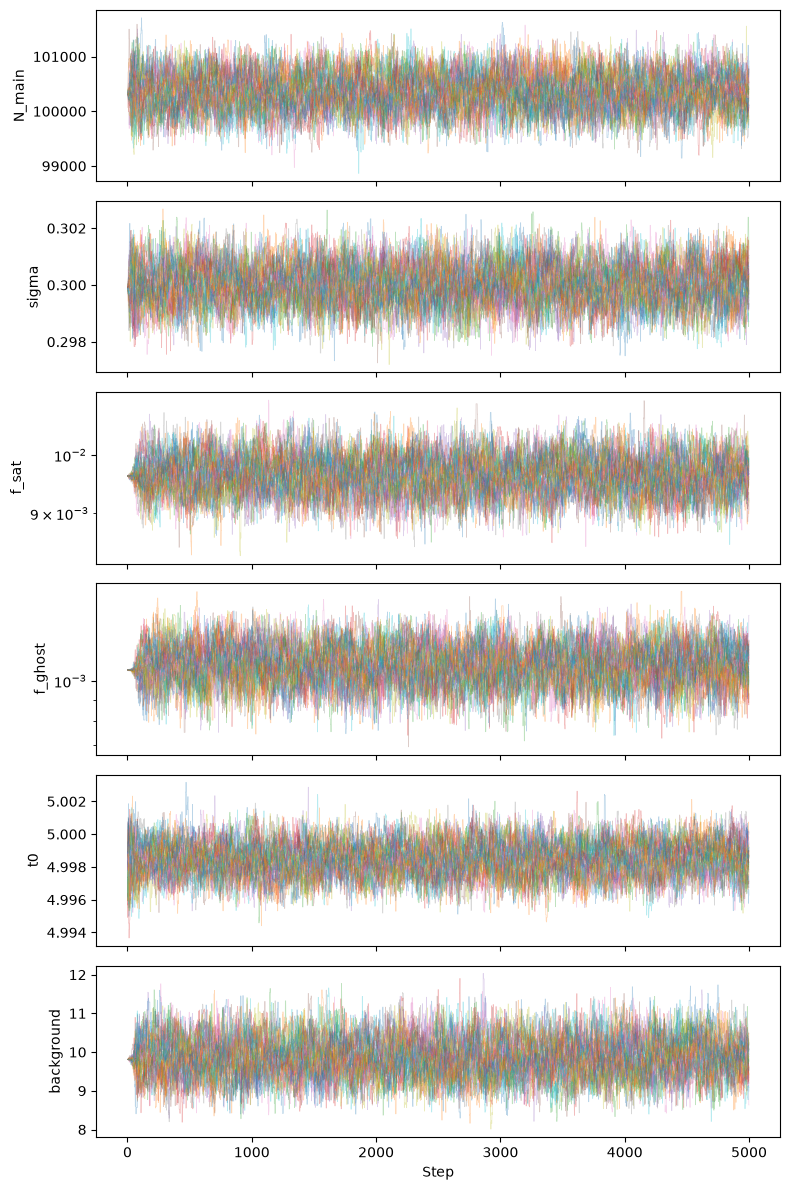

In [3]:
# trace plots
fig = plot_traces(samples, PARAM_NAMES, log_params=LOG_PARAMS)

Convergence -> walkers overlap, no upward/downward drift, no walker stuck in a separate band.
1. Stationarity. Each panel has a constant mean and constant variance across the whole x-axis. No drift up/down, no widening or shrinking. 
2. Mixing. The (walkers) are fully interleaved -> walkers are exploring the same distribution, not each stuck in its own mode.
3. No stuck walkers / no outlier bands. No horizontal line sitting at a weird value, no walker parked at a prior edge.

### 2. Corner plot - recovering theta parameters from data

In [ ]:
THETA_TRUE = [1e5, 0.3, 1e-2, 1e-3, 5.0, 10.0]

flat = samples.reshape(-1, samples.shape[-1])  # or backend.get_chain(flat=True)
print("flat shape:", flat.shape)

flat shape: (160000, 6)


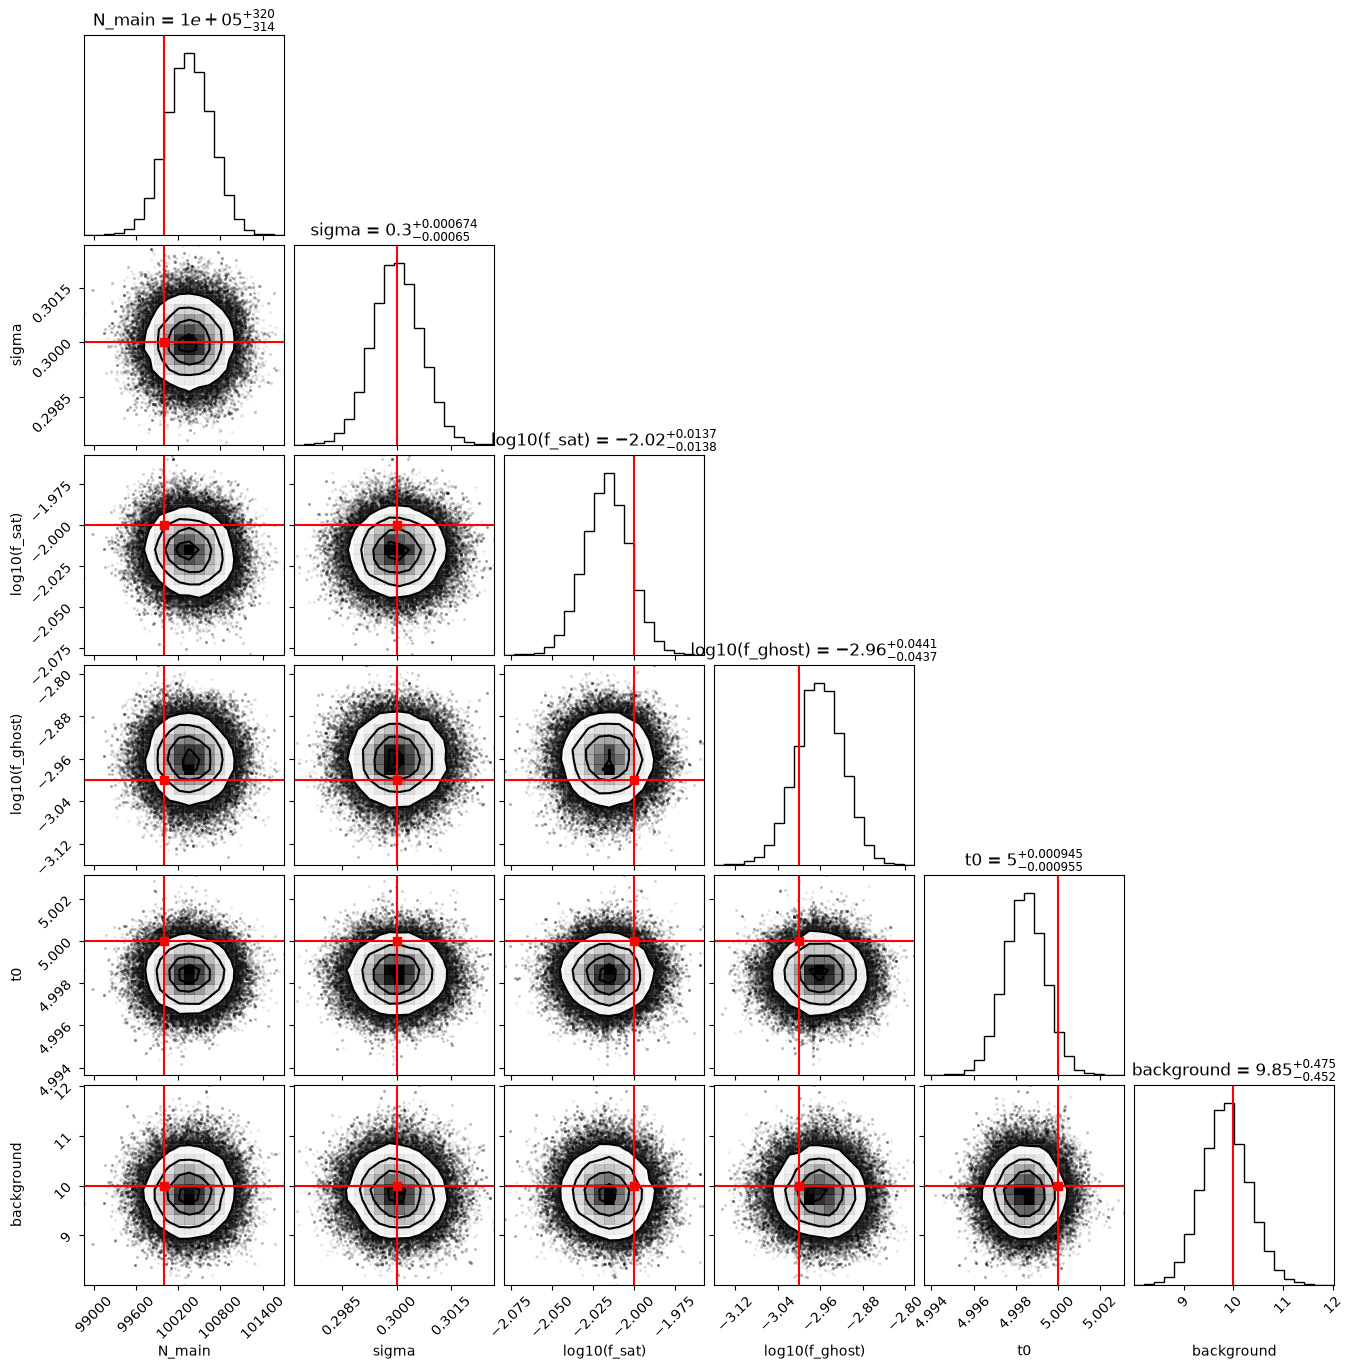

In [6]:
fig = corner_plot(flat, PARAM_NAMES, truth=THETA_TRUE, log_params=LOG_PARAMS)

Observations:
- Contours are near-circular, not tilted ellipses -> parameters are approximately independent, data has enough information to separate the main-bunch amplitude from the satellite fraction from the background.
- f_ghost is 3× less precise than f_sat in log units

| Param            | Truth   | Posterior median | Precision      | Verdict                                          |
|------------------|---------|------------------|----------------|--------------------------------------------------|
| N_main           | 100 000 | ~100 200         | ±0.3%          | recovered                                        |
| sigma            | 0.300   | 0.3000           | ±0.3%          | recovered                                        |
| log10(f_sat)     | −2.00   | −2.02 ± 0.014    | ~3% linear     | recovered, truth on the upper 1.5σ edge          |
| log10(f_ghost)   | −3.00   | −2.96 ± 0.044    | ~10% linear    | weakest          |
| t0               | 5.000   | 5.000            | ±0.001 ns      | great (dominant peak)                |
| background       | 10.0    | 9.85 ± 0.46      | ~5%            | recovered                                        |

### 3. Arviz summart (N_eff and R̂)

In [ ]:
summary = arviz_summary(samples, PARAM_NAMES)
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
N_main,100357.8031,317.1725,99851.7047,100866.4327,2345.1597,4657.5901,1.0156,6.5562,4.5747
sigma,0.3000,0.0007,0.2990,0.3011,2250.5228,4373.2178,1.0125,0.0000,0.0000
f_sat,0.0096,0.0003,0.0092,0.0101,2060.3649,4095.1117,1.0142,0.0000,0.0000
f_ghost,0.0011,0.0001,0.0009,0.0013,2209.1660,4605.7972,1.0129,0.0000,0.0000
t0,4.9985,0.0010,4.9969,5.0000,2263.9593,4593.7528,1.0157,0.0000,0.0000
background,9.8604,0.4664,9.1364,10.6261,2073.3514,3998.9453,1.0141,0.0102,0.0074


Observations:
- R̂ ≈ 1.01–1.02 across parameters -> the between-walker and within-walker variances agree to about 1% (=> converged).
- ess_bulk ≈ 2000–2350, ess_tail ≈ 4000–4600. With 5000 × 32 = 160 000 raw draws -> effective efficiency is ~1.4% for bulk and ~2.8% for tails.
- ess_tail(f_sat) = 4095. Rule of thumb for a stable 95th-percentile estimate is ess_tail ≥ 400 (Vehtari et al. 2021)

### 4. 95% credible upper limit on f_sat
A 95% credible upper limit on f_sat is the value U such that P(f_sat < U | data) = 0.95.
 - detected satellite: f_sat = 0.0096 ± 0.0003

In [ ]:
# report the 68% credible interval and the 95% two-sided credible region.
lims = credible_limits(flat, PARAM_NAMES, "f_sat")
print(f"f_sat median         : {lims[0.5]:.4f}")
print(f"f_sat 68% CI         : [{lims[0.16]:.4f}, {lims[0.84]:.4f}]")
print(f"f_sat 95% upper limit: {lims[0.95]:.4f}")

# same for f_ghost
lims_g = credible_limits(flat, PARAM_NAMES, "f_ghost")
print(f"\nf_ghost median       : {lims_g[0.5]:.5f}")
print(f"f_ghost 68% CI       : [{lims_g[0.16]:.5f}, {lims_g[0.84]:.5f}]")
print(f"f_ghost 95% u.l.     : {lims_g[0.95]:.5f}")

f_sat median         : 0.0096
f_sat 68% CI         : [0.0093, 0.0099]
f_sat 95% upper limit: 0.0102

f_ghost median       : 0.00109
f_ghost 68% CI       : [0.00099, 0.00121]
f_ghost 95% u.l.     : 0.00129


#### Credible upper limits

- **Satellite fraction:** f_sat = 0.96% [0.93%, 0.99%] at 68% credibility; 95% upper limit 1.02%.
  Injected truth was 1.00% → recovered within 1σ.
- **Ghost fraction:** f_ghost = 0.11% [0.099%, 0.121%] at 68% credibility; 95% upper limit 0.129%.
  Injected truth was 0.10% → recovered within 1σ.